In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import * 
import gc,shutil,os, zipfile, subprocess
from pathlib import Path 

"""Init PySpark optimize for Kaggle"""
spark = (SparkSession.builder
    .appName("Telegram-Network-Pipeline")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.driver.memory", "10g")
    .getOrCreate())

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/03 07:08:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [17]:
# Xóa file zip cụ thể
!rm /kaggle/working/channels_10_parquet.zip

# Xóa toàn bộ thư mục temp_extract (bao gồm cả các file con bên trong)
!rm -rf /kaggle/working/temp_extract

In [2]:
def process_single_parquet(path, output_edges_dir, output_profiles_dir):
    df = None
    try:
        raw_df = spark.read.parquet(str(path))
        needed_cols = ["political", "language", "from_id", "chain_from_id", "message_id", "toxicity", "forward", "views"]
        available_cols = [c for c in needed_cols if c in raw_df.columns]
        df = raw_df.select(*available_cols).filter((col("political") == 1) & (col("language") == "en"))
        if df.rdd.isEmpty():
            return
        if "chain_from_id" in df.columns:
            edges = df.filter(col("chain_from_id").isNotNull()) \
                .select(col("from_id").alias("source"), col("chain_from_id").alias("target")) \
                .groupBy("source", "target").count()
            edges.write.mode("append").parquet(output_edges_dir)
        agg_cols = [
            avg("toxicity").alias("avg_toxicity"), 
            count("message_id").alias("msg_count")
        ]
        
        if "views" in df.columns:
            agg_cols.append(avg("views").alias("avg_views"))
            
        if "forward" in df.columns:
            agg_cols.append((sum(when(col("forward") == 1, 1).otherwise(0)) / count("*")).alias("forward_ratio"))
            
        profiles = df.groupBy("from_id").agg(*agg_cols)
        profiles.write.mode("append").parquet(output_profiles_dir)
        
    except Exception as e:
        print(f"Lỗi thực sự tại file {path}: {str(e)}")
    finally:
        if df is not None:
            del df
        spark.catalog.clearCache()
        gc.collect()

In [3]:
# Tắt bớt log của Spark để không bị treo trình duyệt (Rất quan trọng!)
spark.sparkContext.setLogLevel("ERROR")

HF_BASE = "https://huggingface.co/datasets/Tungtom2004/Telegram_politic_dataset/resolve/main"
ZIP_FILES = [f"channels_{i}_parquet.zip" for i in range(10, 12)]

FINAL_EDGES = "/kaggle/working/data/final_edges"
FINAL_PROFILES = "/kaggle/working/data/final_profiles"
TEMP_DIR = Path("/kaggle/working/temp_extract")
TEMP_DIR.mkdir(parents=True, exist_ok=True)

for zip_name in ZIP_FILES:
    zip_path = f'/kaggle/working/{zip_name}'
    
    print(f"--- Loading: {zip_name} ---")
    subprocess.run(["wget", "-q", "-O", zip_path, f"{HF_BASE}/{zip_name}"]) 
    if not os.path.exists(zip_path) or os.path.getsize(zip_path) < 1000:
        print(f"Skip {zip_name} by loading error")
        continue

    print(f"--- Processing handle {zip_name} ---")
    with zipfile.ZipFile(zip_path, 'r') as z:
        parquet_names = [n for n in z.namelist() if n.endswith(".parquet")]
        for member in parquet_names:
            try:
                z.extract(member, TEMP_DIR)
                parquet_path = TEMP_DIR / member
                process_single_parquet(parquet_path, FINAL_EDGES, FINAL_PROFILES)
                if parquet_path.exists():
                    os.remove(parquet_path)
            except Exception as e:
                print(f"Error in {member}: {e}")
                continue
    shutil.rmtree(TEMP_DIR)
    TEMP_DIR.mkdir(parents=True, exist_ok=True)
    if os.path.exists(zip_path):
        os.remove(zip_path)
        print(f"Remove ZIP file and complete: {zip_name}")

print("Finish")

--- Đang tải: channels_10_parquet.zip ---
--- Đang xử lý các file bên trong channels_10_parquet.zip ---


Đã xóa file ZIP và hoàn thành: channels_10_parquet.zip
--- Đang tải: channels_11_parquet.zip ---
--- Đang xử lý các file bên trong channels_11_parquet.zip ---
Đã xóa file ZIP và hoàn thành: channels_11_parquet.zip
TOÀN BỘ PIPELINE ĐÃ HOÀN THÀNH!


In [4]:
from pyspark.sql import functions as F 

edges_final = spark.read.parquet("/kaggle/working/data/final_edges") \
    .groupBy("source", "target") \
    .agg(F.sum("count").alias("weight"))

profiles_final = spark.read.parquet("/kaggle/working/data/final_profiles") \
    .groupBy("from_id") \
    .agg(
        F.sum("msg_count").alias("total_msgs"),
        (F.sum(F.col("avg_toxicity") * F.col("msg_count")) / F.sum("msg_count")).alias("toxicity"),
        (F.sum(F.col("avg_views") * F.col("msg_count")) / F.sum("msg_count")).alias("views"),
        (F.sum(F.col("forward_ratio") * F.col("msg_count")) / F.sum("msg_count")).alias("forward_ratio")
    )

df_edges = edges_final.toPandas()
df_profiles = profiles_final.toPandas()

print(f"Number of edges: {len(df_edges)}")
print(f"Number of profiles: {len(df_profiles)}")

Number of edges: 57798
Number of profiles: 31613


In [6]:
import networkx as nx 

G = nx.DiGraph()

for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

pagerank = nx.pagerank(G, weight="weight")
in_deg = dict(G.in_degree(weight = "weight"))
out_deg = dict(G.out_degree(weight = "weight"))

df_profiles['pagerank'] = df_profiles['from_id'].map(pagerank).fillna(0)
df_profiles['in_degree_w'] = df_profiles['from_id'].map(in_deg).fillna(0)
df_profiles['out_degree_w'] = df_profiles['from_id'].map(out_deg).fillna(0)

print(f"Top 5 channels have the highest pagerank")
print(df_profiles.nlargest(5, "pagerank")[["from_id", "pagerank"]])

Top 5 channels have the highest pagerank
                  from_id  pagerank
21748                      0.490369
3994   channel_1205299143  0.001334
10463  channel_1193871734  0.000427
26335  channel_1235322843  0.000387
21783  channel_1341403870  0.000286


In [7]:
from networkx.algorithms.community import louvain_communities

G_undirected = G.to_undirected()
communities = louvain_communities(G_undirected,weight = "weight",seed = 42)
community_map = {node: idx for idx, comm in enumerate(communities) for node in comm}
df_profiles["community"] = df_profiles["from_id"].map(community_map).fillna(-1)

print(f"Found {len(communities)} communities")

Found 731 communities


In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = ["toxicity", "forward_ratio", "pagerank", "views"]
X = df_profiles[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
df_profiles["cluster"] = kmeans.fit_predict(X_scaled)

df_profiles.to_csv("final_telegram_archetypes.csv", index=False)
print("Done")

Done


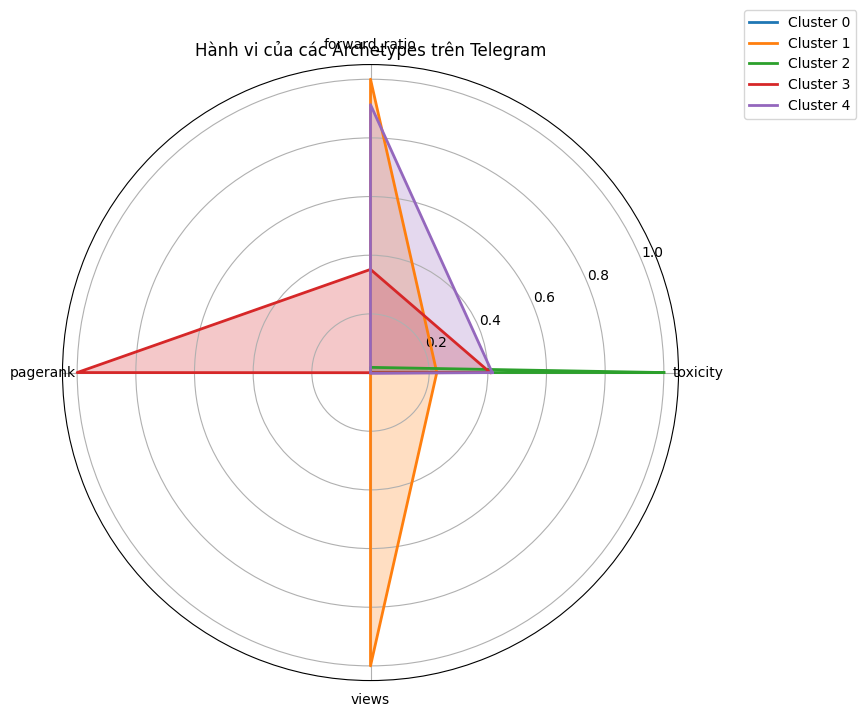

In [10]:
import matplotlib.pyplot as plt
import numpy as np

cluster_summary = df_profiles.groupby("cluster")[features].mean()
cluster_summary_norm = (cluster_summary - cluster_summary.min()) / (cluster_summary.max() - cluster_summary.min())

labels = np.array(features)
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] 

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i in range(len(cluster_summary_norm)):
    values = cluster_summary_norm.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("The behavior of Archetypes on Telegram")
plt.show()

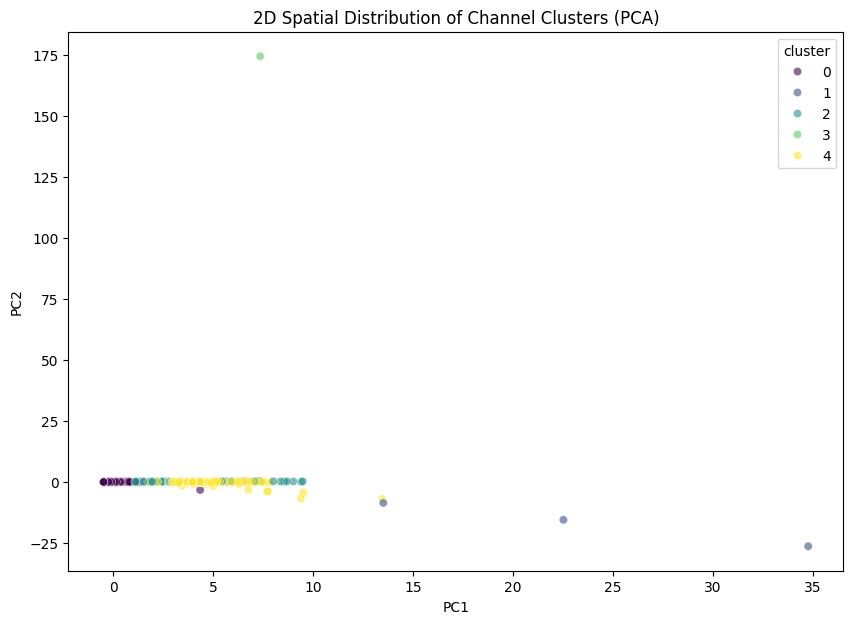

In [14]:
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd 

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
df_pca['cluster'] = df_profiles['cluster'].values

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_pca, palette='viridis', alpha=0.6)
plt.title("2D Spatial Distribution of Channel Clusters (PCA)")
plt.show()

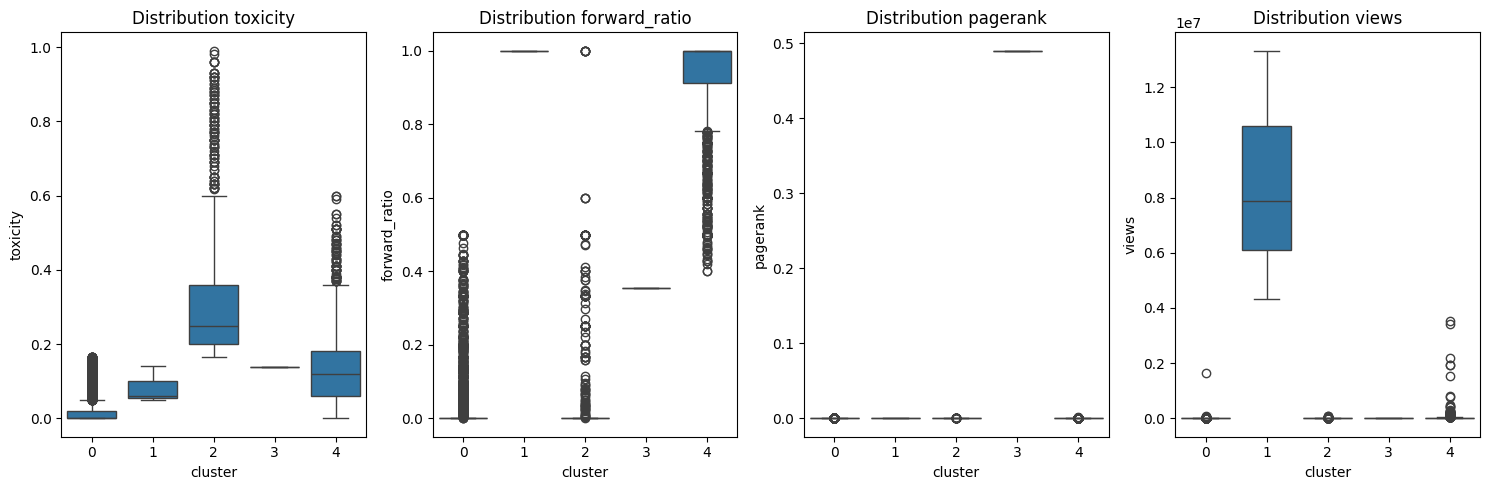

In [15]:
plt.figure(figsize=(15, 5))
for i, feature in enumerate(features):
    plt.subplot(1, 4, i+1)
    sns.boxplot(x='cluster', y=feature, data=df_profiles)
    plt.title(f"Distribution {feature}")
plt.tight_layout()
plt.show()